In [1]:
from datetime import datetime

In [2]:
import arcgis
from arcgis.gis import GIS

gis = GIS("https://pythonapi.playground.esri.com/portal", "arcgis_python", "amazing_arcgis_123")
gis

GIS @ https://pythonapi.playground.esri.com/portal version:7.1

In [3]:
arcgis.env.verbose=True

In [4]:
in_features=gis.content.search("sf_custs_shp",item_type="Feature Layer Collection")[0].layers[0]
in_features

<FeatureLayer url:"https://pythonapi.playground.esri.com/server/rest/services/Hosted/sf_custs_shp/FeatureServer/0">

Interpolate points optimized for speed

In [5]:
interpolate_points_1 = arcgis.raster.analytics.interpolate_points(input_point_features=in_features,
                                                                  interpolate_field="SALES",
                                                                  optimize_for="SPEED", 
                                                                  transform_data=True, 
                                                                  size_of_local_models=50,
                                                                  number_of_neighbors=8,
                                                                  output_cell_size={"distance":50,"units":"Meters"},
                                                                  output_prediction_error=False,
                                                                  gis=gis)
interpolate_points_1

Submitted.
Executing...
InterpolatePoints GP Job: j7ba4a8cac4e24d5c83bbe77ce80367ca finished successfully.


FunctionOutput(output_raster=<Item title:"InterpolatePoints_XVU5RN" type:Imagery Layer owner:arcgis_python>, process_info=<IPython.core.display.HTML object>)

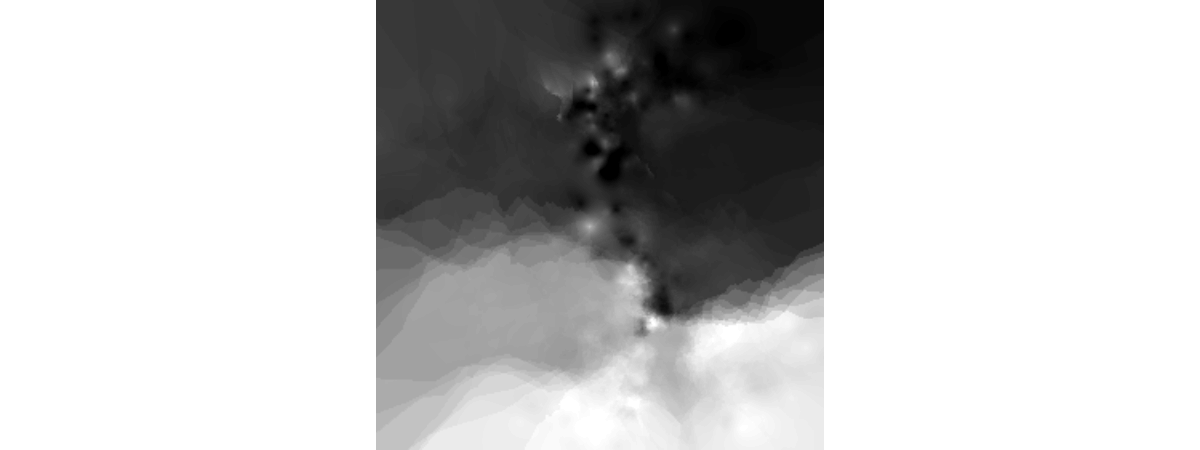

In [6]:
interpolate_points_1.output_raster.layers[0]

In [7]:
interpolate_points_1.process_info

Mean Error,-0.140431656299907
Root Mean Square,47.926650839236
Average Standard,48.9031049373546
Mean Standardized,0.00198566839831761
Root Mean Square Standardized,0.979493038552781


Interpolate points with output_prediction_error output and environment variable analysis_extent set

In [8]:
aoi = {"type": "extent", "xmin": -13633946.5247196, "ymin": 4544946.0757069, "xmax": -13624287.111718, "ymax": 4552826.60826073, "spatialReference": {"wkid": 3857}}

In [9]:
arcgis.env.analysis_extent = aoi
op_folder_name = "interpolate_points" + str(datetime.now().strftime('%Y%m%d%H%M%S'))
interpolate_points_2 = arcgis.raster.analytics.interpolate_points(input_point_features=in_features,
                                                                  interpolate_field="SALES",
                                                                  optimize_for="SPEED", 
                                                                  transform_data=True, 
                                                                  size_of_local_models=50,
                                                                  number_of_neighbors=8,
                                                                  output_cell_size={"distance":50,"units":"Meters"},
                                                                  output_prediction_error=True,
                                                                  output_name="interpolate_points_" + str(datetime.now().strftime('%Y%m%d%H%M%S')), 
                                                                  gis=gis, 
                                                                  folder=op_folder_name)

Submitted.
Executing...
InterpolatePoints GP Job: j5d024dc65aaf4c2aab7799af107f3b27 finished successfully.


In [10]:
interpolate_points_2

FunctionOutput(output_raster=<Item title:"interpolate_points_20191010202705" type:Imagery Layer owner:arcgis_python>, output_error_raster=<Item title:"interpolate_points_20191010202705_Errors" type:Imagery Layer owner:arcgis_python>, process_info=<IPython.core.display.HTML object>)

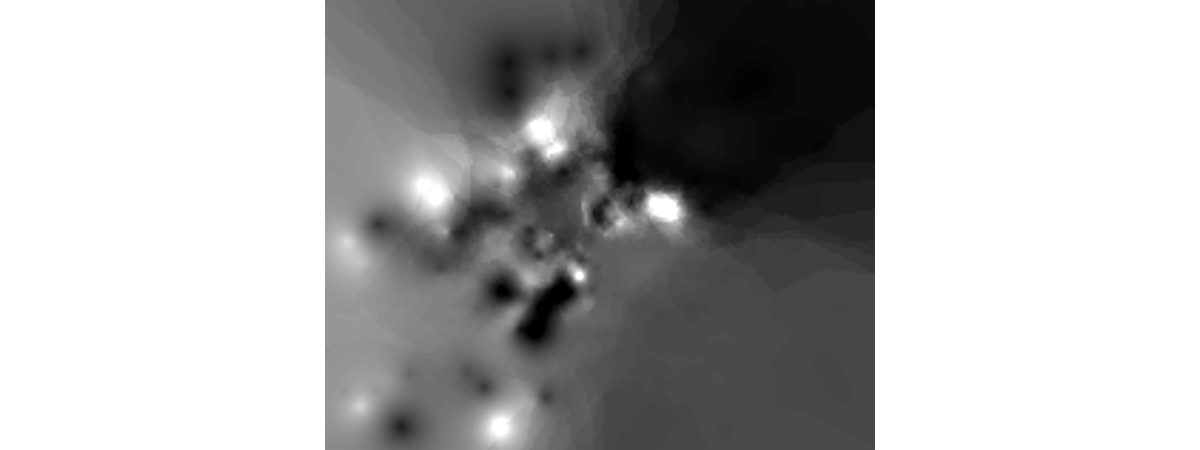

In [11]:
interpolate_points_2.output_raster.layers[0]

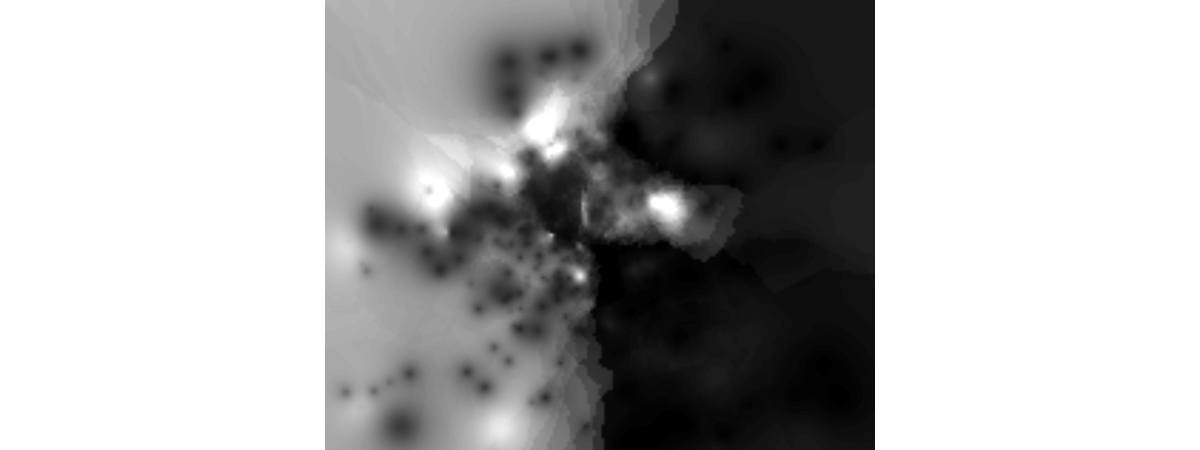

In [12]:
interpolate_points_2.output_error_raster.layers[0]

In [13]:
interpolate_points_2.process_info

Mean Error,0.656701036501628
Root Mean Square,38.2172406791337
Average Standard,39.8903720741673
Mean Standardized,0.0175289019676779
Root Mean Square Standardized,0.976620158546817


In [14]:
arcgis.env.analysis_extent = None

Interpolate points with context param value set

In [15]:
arcgis.env.analysis_extent = {"type": "extent", "xmin": -13633946.5247196, "ymin": 4544946.0757069, "xmax": -13624287.111718, "ymax": 4552826.60826073, "spatialReference": {"wkid": 3857}}

In [16]:
interpolate_points_3=arcgis.raster.analytics.interpolate_points(input_point_features=in_features,
                                                                interpolate_field="SALES",
                                                                optimize_for="ACCURACY", 
                                                                transform_data=True, 
                                                                size_of_local_models=50,
                                                                number_of_neighbors=8,
                                                                output_cell_size={"distance":100,"units":"Meters"},
                                                                output_prediction_error=False,
                                                                output_name="interpolate_points_" + str(datetime.now().strftime('%Y%m%d%H%M%S')),
                                                                gis=gis, 
                                                                future=True,
                                                                context={"extent":aoi},
                                                                folder=op_folder_name)
interpolate_points_3.result()

Submitted.
Executing...
InterpolatePoints GP Job: j10602adb27c444c7a0c46dcefceb955f finished successfully.


FunctionOutput(output_raster=<Item title:"interpolate_points_20191010203016" type:Imagery Layer owner:arcgis_python>, process_info=<IPython.core.display.HTML object>)

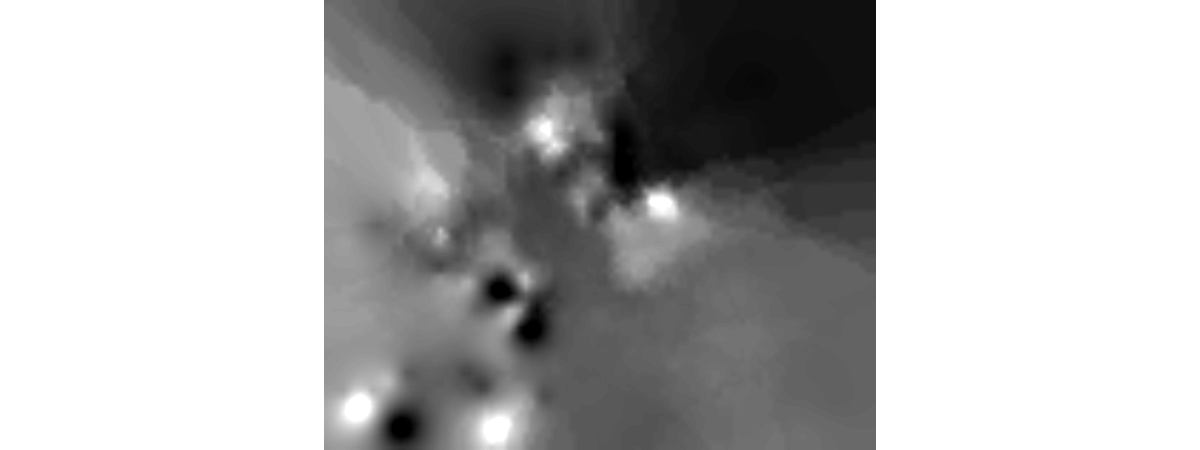

In [17]:
interpolate_points_3.result().output_raster.layers[0]

In [18]:
interpolate_points_3.result().process_info

Mean Error,1.09724244243489
Root Mean Square,38.1663228576071
Average Standard,39.449468952183
Mean Standardized,0.0344883422387278
Root Mean Square Standardized,0.956859428752015


<h4> Clean Up

In [19]:
interpolate_points_1.output_raster.delete()

True

In [20]:
gis.content.delete_folder(op_folder_name)

True